In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# Read NuSyst Tree ROOT file

In [3]:
with uproot.open("/exp/dune/app/users/jskim/DDAS2026/DDAS2026_NuSyst/Tutorial_Part1/NuSystTree.root") as f:

    df_event = f["events"].arrays(library="ak")
    df_meta = f["tweak_metadata"].arrays(library="ak")

# Let's first look at the metadata tree

In [4]:
df_meta

<Array [{fUniqueID: 0, fBits: ..., ...}, ...] type='2 * {fUniqueID: uint32,...'>

Metadata contains the dial and and its list of variations used when running `DumpConfiguredTweaksNuSyst`.
- Each row is for each dial
- "fString": "Full" name of the dial
  - <tool_type>_<instance_name>_<dial name>
- "ntweaks": Number of variations
- "Tweakvalues": Array of the variation

# Now let's look at the event tree

In [5]:
df_event.show(5)

[{Mode: -26, Mode_str: ..., ...},
 {Mode: 26, Mode_str: ..., ...},
 {Mode: -26, Mode_str: ..., ...},
 ...,
 {Mode: 26, Mode_str: ..., ...}]


Event tree converts GENIE Event info into a simple flat tree.
Each row corresponds to a single GENIE interaction.
It contains various kinematic variables that desecribes the interaction.

For instance, we have neutrino energy in "Enu_true":

(array([ 11.,  86., 193., 154.,  68.,  56.,  42.,  40.,  25.,  28.,  35.,
         26.,  30.,  27.,  29.,  14.,  23.,  26.,  15.,  16.,  19.,   9.,
         14.,  11.,  18.,   8.,  10.,   7.,  12.,   6.,  15.,  10.,  12.,
          8.,   8.,   7.,   9.,   7.,   5.,   4.,   8.,   5.,   8.,   5.,
          2.,   3.,   2.,   8.,   3.,   5.,   0.,   3.,   1.,   5.,   2.,
          2.,   2.,   4.,   3.,   0.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
        39., 40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51.,
        52., 53., 54., 55., 56., 57., 58., 59., 60.]),
 <BarContainer object of 60 artists>)

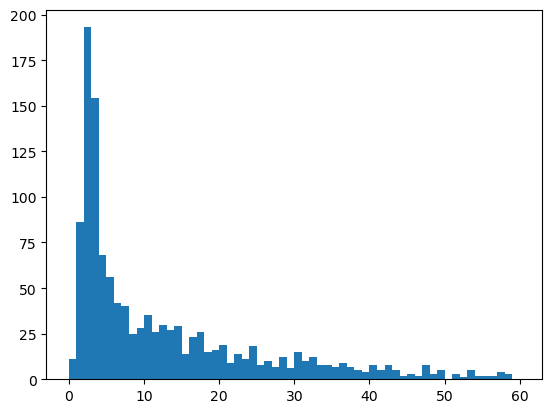

In [7]:
plt.hist(df_event["Enu_true"], bins=np.linspace(0, 60, 60+1))

Above should be the same as what you see from the morning session!

Now, let's focus on the last few columns, which contains the reweight information

In [9]:
DialColumnName_prefix = "DUNEDAS2026ExampleReweighter_NuSystTutorial"

DialColNames = [
    f"ntweaks_{DialColumnName_prefix}_DialA",
    f"tweak_responses_{DialColumnName_prefix}_DialA",
    f"paramCVWeight_{DialColumnName_prefix}_DialA",
]

df_event[DialColNames].show(5)

[{ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA: 3, ...},
 {ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA: 3, ...},
 {ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA: 3, ...},
 ...,
 {ntweaks_DUNEDAS2026ExampleReweighter_NuSystTutorial_DialA: 3, ...}]


- "ntweaks_(prefix)_(DialName)"
    - Number of variations for the Dial
    - Same as in the metadata
- "tweak_responses_(prefix)_(DialName)"
    - An array of the reweights for each variation
    - Reweight in this Tree is divided by the reweight of the "central_value"
    - The order of the elements are the same as "tweakvalues" from the metadata
- "paramCVWeight_(prefix)_(DialName)"
    - Reweight for the central_value
    - If the reweight from cental_value is not 1.0, this means we want to apply a "CV" correction using this dial, and the reweights are on top of that correction
    - For this tutorial, let's make RW(central_value) to be 1.0

As you can see, the reweights from the current module is all 1.0, so we stay at the CV.

Now let's modify "DUNEDAS2026ExampleReweighter" module!